In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from datasets import load_dataset
import ast


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Phython\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
df_DA_US = df[df['job_country'] == 'United States']

df_DA_US = df_DA_US.explode('job_skills')
df_DA_US = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_top_pay = df_DA_US.sort_values('median', ascending=False).head(10)

df_DA_Skills = df_DA_US.sort_values('count', ascending=False).head(10).sort_values('median', ascending=False).head(10)




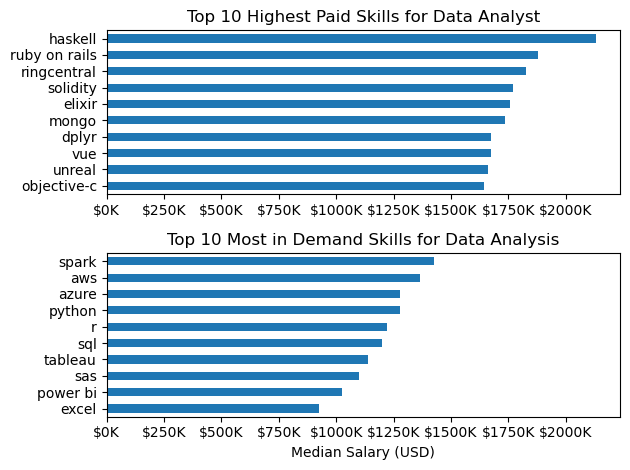

In [21]:
fig, ax = plt.subplots(2, 1)

df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/100)}K'))

df_DA_Skills[::-1].plot(kind='barh', y= 'median', ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_ylabel('')
ax[1].set_title('Top 10 Most in Demand Skills for Data Analysis')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/100)}K'))


fig.tight_layout()